# Phase 1: Exploratory Data Analysis & Data Audit
## Business Entity Resolution Challenge

This notebook performs a comprehensive EDA of the entity resolution dataset.
It covers dataset overview, data quality, name/address noise, ground truth analysis,
true-match characteristics, country analysis, and risk identification.

**Run from the project root directory.**

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
from collections import Counter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paths — resolve relative to this notebook's location
PROJECT_ROOT = Path('..').resolve()
TRAIN_DIR = PROJECT_ROOT / 'dataset' / 'train'
TEST_DIR = PROJECT_ROOT / 'dataset' / 'test'
DOCS_DIR = PROJECT_ROOT / 'docs'
DOCS_DIR.mkdir(exist_ok=True)

# Verify files exist
for f in ['train_source1.tsv', 'train_source2.tsv', 'train_source3.tsv', 'train_ground_truth.tsv']:
    assert (TRAIN_DIR / f).exists(), f"Missing: {TRAIN_DIR / f}"
for f in ['test_source1.tsv', 'test_source2.tsv', 'test_source3.tsv']:
    assert (TEST_DIR / f).exists(), f"Missing: {TEST_DIR / f}"
print("✅ All dataset files found.")

✅ All dataset files found.


## 1. Dataset Overview

In [2]:
# Load all source files
print("Loading datasets (this may take a minute for large files)...")

train_s1 = pd.read_csv(TRAIN_DIR / 'train_source1.tsv', sep='\t', dtype=str)
train_s2 = pd.read_csv(TRAIN_DIR / 'train_source2.tsv', sep='\t', dtype=str)
train_s3 = pd.read_csv(TRAIN_DIR / 'train_source3.tsv', sep='\t', dtype=str)
gt = pd.read_csv(TRAIN_DIR / 'train_ground_truth.tsv', sep='\t', dtype=str)

test_s1 = pd.read_csv(TEST_DIR / 'test_source1.tsv', sep='\t', dtype=str)
test_s2 = pd.read_csv(TEST_DIR / 'test_source2.tsv', sep='\t', dtype=str)
test_s3 = pd.read_csv(TEST_DIR / 'test_source3.tsv', sep='\t', dtype=str)

print("✅ All datasets loaded.")

Loading datasets (this may take a minute for large files)...


✅ All datasets loaded.


In [3]:
# Verify correct parsing (should have 4 columns for source files)
for name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3),
                 ('test_s1', test_s1), ('test_s2', test_s2), ('test_s3', test_s3)]:
    assert df.shape[1] == 4, f"{name} has {df.shape[1]} columns instead of 4. Check sep='\\t'."
    assert list(df.columns) == ['entity_id', 'business_name', 'business_address', 'country'], \
        f"{name} columns mismatch: {list(df.columns)}"
assert gt.shape[1] == 2, f"Ground truth has {gt.shape[1]} columns."
print("✅ All files parsed correctly with tab separator.")

✅ All files parsed correctly with tab separator.


In [4]:
# Dataset overview table
datasets = {
    'train_source1': train_s1,
    'train_source2': train_s2,
    'train_source3': train_s3,
    'test_source1': test_s1,
    'test_source2': test_s2,
    'test_source3': test_s3,
}

overview_rows = []
for name, df in datasets.items():
    row = {
        'Dataset': name,
        'Rows': len(df),
        'Columns': df.shape[1],
        'Unique entity_id': df['entity_id'].nunique(),
        'Duplicate entity_ids': len(df) - df['entity_id'].nunique(),
        'Fully Duplicated Rows': df.duplicated().sum(),
    }
    overview_rows.append(row)

overview_df = pd.DataFrame(overview_rows)
print("\n📊 Dataset Overview:")
print(overview_df.to_string(index=False))


📊 Dataset Overview:
      Dataset    Rows  Columns  Unique entity_id  Duplicate entity_ids  Fully Duplicated Rows
train_source1 2206821        4           2206821                     0                      0
train_source2 5034616        4           5034616                     0                      0
train_source3 5285603        4           5285603                     0                      0
 test_source1 1732544        4           1732544                     0                      0
 test_source2 4887273        4           4887273                     0                      0
 test_source3 5082316        4           5082316                     0                      0


In [5]:
# Missing / null / empty values per column per dataset
print("\n📊 Missing/Null/Empty Values Analysis:")
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    for col in df.columns:
        null_count = df[col].isna().sum()
        empty_str = (df[col].fillna('') == '').sum() - df[col].isna().sum()  # empty but not null
        whitespace_only = df[col].fillna('').str.strip().eq('').sum() - (df[col].isna().sum() + empty_str)
        total_missing = df[col].isna().sum() + (df[col].fillna('').str.strip() == '').sum() - df[col].isna().sum()
        print(f"  {col}: null={null_count}, empty_string={max(0, empty_str)}, "
              f"whitespace_only={max(0, whitespace_only)}, total_effectively_missing={total_missing}")


📊 Missing/Null/Empty Values Analysis:

--- train_source1 ---


  entity_id: null=0, empty_string=0, whitespace_only=0, total_effectively_missing=0


  business_name: null=0, empty_string=0, whitespace_only=0, total_effectively_missing=0


  business_address: null=0, empty_string=0, whitespace_only=0, total_effectively_missing=0


  country: null=0, empty_string=0, whitespace_only=0, total_effectively_missing=0

--- train_source2 ---


...

  country: null=0, empty_string=0, whitespace_only=0, total_effectively_missing=0

--- test_source3 ---


  entity_id: null=0, empty_string=0, whitespace_only=0, total_effectively_missing=0


  business_name: null=59, empty_string=0, whitespace_only=0, total_effectively_missing=59


  business_address: null=136098, empty_string=0, whitespace_only=0, total_effectively_missing=136098


  country: null=0, empty_string=0, whitespace_only=0, total_effectively_missing=0


In [6]:
# Country distribution for all datasets
print("\n📊 Country Distribution:")
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    country_counts = df['country'].value_counts(dropna=False)
    for country, count in country_counts.items():
        pct = count / len(df) * 100
        print(f"  {country}: {count:,} ({pct:.1f}%)")


📊 Country Distribution:

--- train_source1 ---
  US: 1,323,633 (60.0%)
  India: 883,188 (40.0%)

--- train_source2 ---
  US: 3,016,817 (59.9%)
  India: 2,017,799 (40.1%)

--- train_source3 ---


  US: 3,170,056 (60.0%)
  India: 2,115,547 (40.0%)

--- test_source1 ---
  India: 809,986 (46.8%)
  US: 663,106 (38.3%)
  France: 259,452 (15.0%)

--- test_source2 ---
  India: 2,312,565 (47.3%)
  US: 1,871,330 (38.3%)
  France: 703,378 (14.4%)

--- test_source3 ---
  India: 2,405,000 (47.3%)
  US: 1,945,701 (38.3%)
  France: 731,615 (14.4%)


In [7]:
# Name length statistics
print("\n📊 Name Length Statistics:")
for name, df in datasets.items():
    name_lens = df['business_name'].fillna('').str.len()
    print(f"\n--- {name} ---")
    print(f"  min={name_lens.min()}, max={name_lens.max()}, mean={name_lens.mean():.1f}, "
          f"median={name_lens.median():.1f}, std={name_lens.std():.1f}")
    print(f"  Very short (≤3 chars): {(name_lens <= 3).sum()} ({(name_lens <= 3).mean()*100:.2f}%)")
    print(f"  Very long (>100 chars): {(name_lens > 100).sum()} ({(name_lens > 100).mean()*100:.2f}%)")


📊 Name Length Statistics:



--- train_source1 ---
  min=3, max=105, mean=24.0, median=24.0, std=7.7
  Very short (≤3 chars): 561 (0.03%)
  Very long (>100 chars): 2 (0.00%)



--- train_source2 ---
  min=0, max=104, mean=25.1, median=25.0, std=8.9
  Very short (≤3 chars): 2946 (0.06%)
  Very long (>100 chars): 3 (0.00%)



--- train_source3 ---
  min=0, max=123, mean=25.2, median=25.0, std=9.5
  Very short (≤3 chars): 17006 (0.32%)
  Very long (>100 chars): 3 (0.00%)



--- test_source1 ---
  min=3, max=92, mean=23.8, median=24.0, std=7.7
  Very short (≤3 chars): 285 (0.02%)
  Very long (>100 chars): 0 (0.00%)



--- test_source2 ---
  min=0, max=102, mean=25.7, median=25.0, std=9.1
  Very short (≤3 chars): 12559 (0.26%)
  Very long (>100 chars): 1 (0.00%)



--- test_source3 ---
  min=0, max=103, mean=25.7, median=25.0, std=9.6
  Very short (≤3 chars): 27142 (0.53%)
  Very long (>100 chars): 3 (0.00%)


In [8]:
# Address length statistics
print("\n📊 Address Length Statistics:")
for name, df in datasets.items():
    addr_lens = df['business_address'].fillna('').str.len()
    print(f"\n--- {name} ---")
    print(f"  min={addr_lens.min()}, max={addr_lens.max()}, mean={addr_lens.mean():.1f}, "
          f"median={addr_lens.median():.1f}, std={addr_lens.std():.1f}")
    print(f"  Empty addresses: {(addr_lens == 0).sum()} ({(addr_lens == 0).mean()*100:.2f}%)")
    print(f"  Very long (>200 chars): {(addr_lens > 200).sum()} ({(addr_lens > 200).mean()*100:.2f}%)")


📊 Address Length Statistics:



--- train_source1 ---
  min=11, max=256, mean=52.1, median=41.0, std=25.3
  Empty addresses: 0 (0.00%)
  Very long (>200 chars): 52 (0.00%)



--- train_source2 ---
  min=0, max=249, mean=46.2, median=37.0, std=24.8
  Empty addresses: 168967 (3.36%)
  Very long (>200 chars): 53 (0.00%)



--- train_source3 ---
  min=0, max=240, mean=46.7, median=42.0, std=21.6
  Empty addresses: 175916 (3.33%)
  Very long (>200 chars): 58 (0.00%)



--- test_source1 ---
  min=11, max=268, mean=57.2, median=50.0, std=25.0
  Empty addresses: 0 (0.00%)
  Very long (>200 chars): 63 (0.00%)



--- test_source2 ---
  min=0, max=269, mean=50.4, median=43.0, std=25.3
  Empty addresses: 129408 (2.65%)
  Very long (>200 chars): 126 (0.00%)



--- test_source3 ---
  min=0, max=267, mean=48.7, median=43.0, std=22.6
  Empty addresses: 136098 (2.68%)
  Very long (>200 chars): 108 (0.00%)


## 2. Data Quality Investigation

In [9]:
# Duplicate IDs check
print("📊 Duplicate Entity IDs:")
for name, df in datasets.items():
    dup_ids = df[df['entity_id'].duplicated(keep=False)]
    if len(dup_ids) > 0:
        print(f"  {name}: {df['entity_id'].duplicated().sum()} duplicate ID entries")
        print(f"    Example duplicated IDs: {dup_ids['entity_id'].value_counts().head(3).to_dict()}")
    else:
        print(f"  {name}: No duplicate IDs ✅")

📊 Duplicate Entity IDs:


  train_source1: No duplicate IDs ✅


  train_source2: No duplicate IDs ✅


  train_source3: No duplicate IDs ✅


  test_source1: No duplicate IDs ✅


  test_source2: No duplicate IDs ✅


  test_source3: No duplicate IDs ✅


In [10]:
# Duplicate names check
print("\n📊 Duplicate Business Names (exact):")
for name, df in datasets.items():
    name_counts = df['business_name'].dropna().value_counts()
    dup_names = name_counts[name_counts > 1]
    print(f"  {name}: {len(dup_names)} names appear more than once, "
          f"covering {dup_names.sum()} records")
    if len(dup_names) > 0:
        print(f"    Top 5 repeated names: {dup_names.head(5).to_dict()}")


📊 Duplicate Business Names (exact):


  train_source1: 177793 names appear more than once, covering 845385 records
    Top 5 repeated names: {'Primary Care Group': 253, 'Ear Nose & Throat Group': 251, 'Pediatric Group': 222, 'Womens Health Group': 220, 'Physical Therapy Group': 218}


  train_source2: 239778 names appear more than once, covering 872384 records
    Top 5 repeated names: {'Primary Care': 320, 'Physical Therapy': 307, 'Womens Health': 297, 'Urgent Care': 297, 'Behavioral Health': 296}


  train_source3: 258275 names appear more than once, covering 892257 records
    Top 5 repeated names: {'Primary Care': 421, 'Physical Therapy': 399, 'Pediatric Dental': 393, 'Womens Health': 379, 'Urgent Care': 377}


  test_source1: 129955 names appear more than once, covering 623632 records
    Top 5 repeated names: {'Bordeaux Club SARL': 205, 'Nantes Club SARL': 157, 'Lille Club SARL': 147, 'Urgent Care Group': 123, 'Lille Club SAS': 122}


  test_source2: 223102 names appear more than once, covering 799289 records
    Top 5 repeated names: {'CC': 302, 'PC': 197, 'LC': 194, 'AC': 174, 'SC': 174}


  test_source3: 238155 names appear more than once, covering 798484 records
    Top 5 repeated names: {'CC': 387, 'SC': 358, 'AC': 297, 'PC': 286, 'LC': 245}


In [11]:
# Duplicate addresses check
print("\n📊 Duplicate Business Addresses (exact):")
for name, df in datasets.items():
    addr_counts = df['business_address'].dropna().value_counts()
    dup_addrs = addr_counts[addr_counts > 1]
    print(f"  {name}: {len(dup_addrs)} addresses appear more than once, "
          f"covering {dup_addrs.sum()} records")
    if len(dup_addrs) > 0:
        print(f"    Top 5 repeated addresses: {dup_addrs.head(5).to_dict()}")


📊 Duplicate Business Addresses (exact):


  train_source1: 40089 addresses appear more than once, covering 116304 records
    Top 5 repeated addresses: {'108 Norle Street, College Twp, PA': 14, '1921 Willow Park Drive, Fort Worth, TX': 13, '55, Lavkush Vihar, Singhpur, Kachhar Bithoor Road, Kalyanpur, Kanpur Nagar, Uttar Pradesh': 13, '104 Roadrunner Circle, Elephant Butte, NM': 13, '43 Franklin Street, Delaware, OH': 13}


  train_source2: 421472 addresses appear more than once, covering 949860 records
    Top 5 repeated addresses: {'842 38, CALEDONAI TOWNSHIP, WI': 18, '1948 WEAVER FOREST WAY, MORRISVILLE, NC': 18, '66 FRANK EDGE, ALTO, TX': 17, '302 REGENCY CT, AMES, IA': 16, 'G-58/1, BENSON CROSS ROAD, BANGALORE., Karnataka': 16}


  train_source3: 382890 addresses appear more than once, covering 859813 records
    Top 5 repeated addresses: {'Ground Floor, Bangalore, KA': 29, 'Floor, Mumbai, MH': 26, '18, Kolkata, Howrah, WB': 26, '303, Mumbai, MH': 25, '12, Ahmedabad, GJ': 23}


  test_source1: 31396 addresses appear more than once, covering 86457 records
    Top 5 repeated addresses: {'12 RUE Lyderic, Lille, Hauts-de-France': 99, '27 RUE Jean Bart, Lille, Hauts-de-France': 85, '30 RUE des Meuniers, Lille, Hauts-de-France': 72, '27 RUE Jean Bart, Maison des Associations, Lille, Hauts-de-France': 67, '100 RUE de Lille, Tourcoing, Hauts-de-France': 46}


  test_source2: 444698 addresses appear more than once, covering 977780 records
    Top 5 repeated addresses: {'CALAIS': 81, '27 RUE JEAN BART, LILLE': 79, 'BORDEAUX': 64, 'RUE LYDERIC, LILLE': 64, '30 RUE DES MEUNIERS, LILLE': 57}


  test_source3: 404756 addresses appear more than once, covering 894539 records
    Top 5 repeated addresses: {'Calais': 89, '27 Rue Jean Bart, Lille': 84, 'Calais, Pas-de-Calais': 74, '12 Rue Lyderic, Lille, Nord': 72, 'Calais, Hauts-de-France': 64}


In [12]:
# Missing names/addresses/countries
print("\n📊 Missing Critical Fields:")
for name, df in datasets.items():
    missing_name = df['business_name'].isna() | (df['business_name'].str.strip() == '')
    missing_addr = df['business_address'].isna() | (df['business_address'].str.strip() == '')
    missing_country = df['country'].isna() | (df['country'].str.strip() == '')
    print(f"  {name}:")
    print(f"    Missing names: {missing_name.sum()} ({missing_name.mean()*100:.2f}%)")
    print(f"    Missing addresses: {missing_addr.sum()} ({missing_addr.mean()*100:.2f}%)")
    print(f"    Missing countries: {missing_country.sum()} ({missing_country.mean()*100:.2f}%)")


📊 Missing Critical Fields:


  train_source1:
    Missing names: 0 (0.00%)
    Missing addresses: 0 (0.00%)
    Missing countries: 0 (0.00%)


  train_source2:
    Missing names: 2 (0.00%)
    Missing addresses: 168967 (3.36%)
    Missing countries: 0 (0.00%)


  train_source3:
    Missing names: 13 (0.00%)
    Missing addresses: 175916 (3.33%)
    Missing countries: 0 (0.00%)


  test_source1:
    Missing names: 0 (0.00%)
    Missing addresses: 0 (0.00%)
    Missing countries: 0 (0.00%)


  test_source2:
    Missing names: 46 (0.00%)
    Missing addresses: 129408 (2.65%)
    Missing countries: 0 (0.00%)


  test_source3:
    Missing names: 59 (0.00%)
    Missing addresses: 136098 (2.68%)
    Missing countries: 0 (0.00%)


In [13]:
# Unicode / unusual character detection
print("\n📊 Character Analysis (sample-based):")
for name, df in datasets.items():
    names = df['business_name'].dropna()
    # Check for non-ASCII
    non_ascii_mask = names.str.contains(r'[^\x00-\x7F]', regex=True, na=False)
    non_ascii_count = non_ascii_mask.sum()
    print(f"\n  {name}:")
    print(f"    Names with non-ASCII chars: {non_ascii_count} ({non_ascii_count/len(names)*100:.2f}%)")
    
    # Devanagari script detection
    devanagari = names.str.contains(r'[\u0900-\u097F]', regex=True, na=False)
    print(f"    Names with Devanagari script: {devanagari.sum()} ({devanagari.mean()*100:.2f}%)")
    
    # Accented Latin chars (common in French)
    accented = names.str.contains(r'[àâäéèêëïîôùûüÿçœæÀÂÄÉÈÊËÏÎÔÙÛÜŸÇŒÆ]', regex=True, na=False)
    print(f"    Names with accented Latin chars: {accented.sum()} ({accented.mean()*100:.2f}%)")
    
    # Unusual punctuation
    unusual_punct = names.str.contains(r'[<>{}|\\~`]', regex=True, na=False)
    print(f"    Names with unusual punctuation (<>{{}}|\\~`): {unusual_punct.sum()}")


📊 Character Analysis (sample-based):



  train_source1:
    Names with non-ASCII chars: 0 (0.00%)


    Names with Devanagari script: 0 (0.00%)


    Names with accented Latin chars: 0 (0.00%)


    Names with unusual punctuation (<>{}|\~`): 116


...

    Names with unusual punctuation (<>{}|\~`): 23698



  test_source3:
    Names with non-ASCII chars: 737515 (14.51%)


    Names with Devanagari script: 181068 (3.56%)


    Names with accented Latin chars: 228611 (4.50%)


    Names with unusual punctuation (<>{}|\~`): 25135


In [14]:
# Capitalization patterns
print("\n📊 Capitalization Patterns in Business Names:")
for name, df in datasets.items():
    names = df['business_name'].dropna()
    all_upper = names.str.match(r'^[^a-z]*$', na=False) & names.str.contains(r'[A-Z]', na=False)
    all_lower = names.str.match(r'^[^A-Z]*$', na=False) & names.str.contains(r'[a-z]', na=False)
    mixed = ~all_upper & ~all_lower
    print(f"\n  {name}:")
    print(f"    ALL UPPER: {all_upper.sum()} ({all_upper.mean()*100:.1f}%)")
    print(f"    all lower: {all_lower.sum()} ({all_lower.mean()*100:.1f}%)")
    print(f"    Mixed case: {mixed.sum()} ({mixed.mean()*100:.1f}%)")


📊 Capitalization Patterns in Business Names:



  train_source1:
    ALL UPPER: 0 (0.0%)
    all lower: 0 (0.0%)
    Mixed case: 2206821 (100.0%)



  train_source2:
    ALL UPPER: 951592 (18.9%)
    all lower: 290121 (5.8%)
    Mixed case: 3792901 (75.3%)



  train_source3:
    ALL UPPER: 156218 (3.0%)
    all lower: 330810 (6.3%)
    Mixed case: 4798562 (90.8%)



  test_source1:
    ALL UPPER: 3 (0.0%)
    all lower: 17 (0.0%)
    Mixed case: 1732524 (100.0%)



  test_source2:
    ALL UPPER: 854953 (17.5%)
    all lower: 245972 (5.0%)
    Mixed case: 3786302 (77.5%)



  test_source3:
    ALL UPPER: 162562 (3.2%)
    all lower: 281830 (5.5%)
    Mixed case: 4637865 (91.3%)


## 3. Business Name Noise Analysis

In [15]:
# Legal suffix variations
legal_suffixes = [
    r'\bInc\.?\b', r'\bIncorporated\b', r'\bCorp\.?\b', r'\bCorporation\b',
    r'\bLLC\b', r'\bLtd\.?\b', r'\bLimited\b', r'\bPvt\.?\b', r'\bPrivate\b',
    r'\bLLP\b', r'\bPLC\b', r'\bGmbH\b', r'\bSARL\b', r'\bSAS\b', r'\bSA\b',
    r'\bCo\.?\b', r'\bCompany\b', r'\bAssociates?\b', r'\bPartners?\b',
    r'\bGroup\b', r'\bHoldings?\b', r'\bEnterprises?\b', r'\bServices?\b',
    r'\bSolutions?\b', r'\bTechnolog(?:y|ies)\b', r'\bIndustries\b',
    r'\bConsultants?\b', r'\bInternational\b', r'\bDBA\b',
]

print("📊 Legal Suffix Prevalence in Business Names:")
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    names = df['business_name'].fillna('')
    print(f"\n--- {ds_name} (n={len(df)}) ---")
    for pattern in legal_suffixes:
        count = names.str.contains(pattern, case=False, regex=True, na=False).sum()
        if count > 0:
            pct = count / len(df) * 100
            print(f"  {pattern}: {count:,} ({pct:.2f}%)")

📊 Legal Suffix Prevalence in Business Names:

--- train_s1 (n=2206821) ---


  \bInc\.?\b: 238,309 (10.80%)


  \bIncorporated\b: 8 (0.00%)


  \bCorp\.?\b: 34,738 (1.57%)


  \bCorporation\b: 14,372 (0.65%)


...

  \bTechnolog(?:y|ies)\b: 57,519 (1.09%)


  \bIndustries\b: 53,419 (1.01%)


  \bConsultants?\b: 25,173 (0.48%)


  \bInternational\b: 32,004 (0.61%)


  \bDBA\b: 31,629 (0.60%)


In [16]:
# & vs "and" patterns
print("\n📊 '&' vs 'and' in Business Names:")
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    names = df['business_name'].fillna('')
    amp_count = names.str.contains(r'&', regex=False, na=False).sum()
    and_count = names.str.contains(r'\band\b', case=False, regex=True, na=False).sum()
    print(f"  {ds_name}: '&'={amp_count:,}, 'and'={and_count:,}")


📊 '&' vs 'and' in Business Names:


  train_s1: '&'=111,897, 'and'=57,296


  train_s2: '&'=209,076, 'and'=118,201


  train_s3: '&'=216,937, 'and'=122,220


In [17]:
# Punctuation patterns in names
print("\n📊 Common Punctuation in Business Names:")
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    names = df['business_name'].fillna('')
    print(f"\n--- {ds_name} ---")
    for char, label in [('.', 'period'), (',', 'comma'), ("'", 'apostrophe'), 
                         ('-', 'hyphen'), ('/', 'slash'), ('"', 'quote'),
                         ('(', 'paren'), ('#', 'hash')]:
        count = names.str.contains(re.escape(char), regex=True, na=False).sum()
        pct = count / len(df) * 100
        print(f"  {label} '{char}': {count:,} ({pct:.2f}%)")


📊 Common Punctuation in Business Names:

--- train_s1 ---


  period '.': 149,075 (6.76%)


  comma ',': 168,736 (7.65%)


  apostrophe ''': 46,606 (2.11%)


  hyphen '-': 13,517 (0.61%)


...

  hyphen '-': 295,428 (5.59%)


  slash '/': 87,248 (1.65%)


  quote '"': 0 (0.00%)


  paren '(': 269,471 (5.10%)


  hash '#': 35,818 (0.68%)


In [18]:
# Names starting with special markers (<<, --, etc.)
print("\n📊 Names with Special Leading Patterns:")
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    names = df['business_name'].fillna('')
    leading_special = names.str.match(r'^[^a-zA-Z0-9\u0900-\u097F]', na=False)
    print(f"  {ds_name}: {leading_special.sum()} names start with non-alphanumeric char")
    if leading_special.sum() > 0:
        examples = names[leading_special].head(5).tolist()
        print(f"    Examples: {examples}")


📊 Names with Special Leading Patterns:


  train_s1: 3181 names start with non-alphanumeric char
    Examples: ['#4 Presidio', '(E) Industries Clinic', '(india) Dhana Risk Private Limited', '(india) Manoj Kriti Private Limited', '# 3 NM Uranium']


  train_s2: 313073 names start with non-alphanumeric char
    Examples: ['-- Holloway Peak Inc Seafood', 'குளோபல் பிசினஸ் பிரைவேட் லிமிடெட்', '[INCORPORATED] PEAK TRADIN6 NETWORKS SOUTHSIDE', 'શક્તિ અર્બન પ્રોડક્ટ્સ પ્રાઇવેટ લિમિટેડ', '*** Country  Real']


  train_s3: 230576 names start with non-alphanumeric char
    Examples: ['#centraleducation', 'அரிஹந்த் Foundation Private Limited', 'സിൽവർ കൺസൾട്ടൻസി പ്രൈവറ്റ് ലിമിറ്റഡ്', 'గుజరాత్ Logistics లిమిటెడ్', '#Apexphotonics']


In [19]:
# Show examples of name noise patterns from training data
print("\n📊 Examples of Name Noise Patterns (from training data):")

# Find names containing "DBA" or "d/b/a" or "doing business as"
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    names = df['business_name'].fillna('')
    dba = names.str.contains(r'\bDBA\b|d/b/a|doing business as', case=False, regex=True, na=False)
    if dba.sum() > 0:
        print(f"\n  DBA patterns in {ds_name}: {dba.sum()}")
        print(f"    Examples: {names[dba].head(3).tolist()}")

# Names ending with .com or .net (web-based names)
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    names = df['business_name'].fillna('')
    dotcom = names.str.contains(r'\.(com|net|org|io)\b', case=False, regex=True, na=False)
    if dotcom.sum() > 0:
        print(f"\n  Web-domain names in {ds_name}: {dotcom.sum()}")
        print(f"    Examples: {names[dotcom].head(3).tolist()}")


📊 Examples of Name Noise Patterns (from training data):



  DBA patterns in train_s1: 6
    Examples: ['Dba Construction Pvt Ltd', 'Dba Brothers Pvt Ltd', 'Dba Polytechnic Private Limited']



  DBA patterns in train_s2: 16
    Examples: ['Smith Smith Dba of Denning', 'DBA', 'Dba Private Limited Center']



  DBA patterns in train_s3: 52411
    Examples: ['Ectolumdrex dba X+ Madison Inc', 'Quonex d/b/a M D Herrera Offshore', 'Umbraonyx dba Filson Apex Chemical']



  Web-domain names in train_s2: 201189
    Examples: ['SHIVSHAKTI VIDYALAYA VIDYALAYA OVERSEAS CORPORATION | www.shivshakti.com', 'heassociates.com', 'prprivate.com']



  Web-domain names in train_s3: 210838
    Examples: ['wilfordhancock.com', 'Hmgreen.Com', 'erwinsignaturekrakacquisition.com']


## 4. Address Noise Analysis

In [20]:
# Address abbreviation patterns
addr_patterns = [
    (r'\bSt\.?\b', 'St/Street'), (r'\bStreet\b', 'Street'),
    (r'\bRd\.?\b', 'Rd/Road'), (r'\bRoad\b', 'Road'),
    (r'\bAve\.?\b', 'Ave/Avenue'), (r'\bAvenue\b', 'Avenue'),
    (r'\bBlvd\.?\b', 'Blvd/Boulevard'), (r'\bBoulevard\b', 'Boulevard'),
    (r'\bDr\.?\b', 'Dr/Drive'), (r'\bDrive\b', 'Drive'),
    (r'\bLn\.?\b', 'Ln/Lane'), (r'\bLane\b', 'Lane'),
    (r'\bCt\.?\b', 'Ct/Court'), (r'\bCourt\b', 'Court'),
    (r'\bPO Box\b', 'PO Box'), (r'\bP\.?O\.?\s*Box\b', 'P.O. Box'),
    (r'\bSuite\b', 'Suite'), (r'\bSte\.?\b', 'Ste'),
    (r'\bApt\.?\b', 'Apt'), (r'\bApartment\b', 'Apartment'),
    (r'\bUnit\b', 'Unit'), (r'\bFloor\b', 'Floor'),
    (r'\bNear\b', 'Near (landmark)'), (r'\bOpp\.?\b', 'Opp (opposite)'),
    (r'\bBehind\b', 'Behind (landmark)'),
]

print("📊 Address Pattern Prevalence:")
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    addrs = df['business_address'].fillna('')
    print(f"\n--- {ds_name} ---")
    for pattern, label in addr_patterns:
        count = addrs.str.contains(pattern, case=False, regex=True, na=False).sum()
        if count > 100:  # Only show if somewhat frequent
            pct = count / len(df) * 100
            print(f"  {label}: {count:,} ({pct:.2f}%)")

📊 Address Pattern Prevalence:



--- train_s1 ---


  St/Street: 16,162 (0.73%)


  Street: 309,331 (14.02%)


  Rd/Road: 19,722 (0.89%)


...

  Unit: 196,849 (3.72%)


  Floor: 277,745 (5.25%)


  Near (landmark): 89,156 (1.69%)


  Opp (opposite): 46,869 (0.89%)


  Behind (landmark): 12,931 (0.24%)


In [21]:
# Landmark-based address references (Indian-style)
print("\n📊 Landmark-Based Address References:")
landmark_patterns = [
    r'\bNear\b', r'\bOpp\.?\b', r'\bOpposite\b', r'\bBehind\b',
    r'\bBeside\b', r'\bAdjacent\b', r'\bNext to\b', r'\bAbove\b',
]
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    addrs = df['business_address'].fillna('')
    for pattern in landmark_patterns:
        count = addrs.str.contains(pattern, case=False, regex=True, na=False).sum()
        if count > 0:
            print(f"  {ds_name} - {pattern}: {count:,}")


📊 Landmark-Based Address References:


  train_s1 - \bNear\b: 57,070


  train_s1 - \bOpp\.?\b: 30,311


  train_s1 - \bOpposite\b: 4,540


  train_s1 - \bBehind\b: 8,313


...

  train_s3 - \bBehind\b: 12,931


  train_s3 - \bBeside\b: 2,923


  train_s3 - \bAdjacent\b: 283


  train_s3 - \bNext to\b: 2,528


  train_s3 - \bAbove\b: 2,545


In [22]:
# Address component analysis — state abbreviations vs full names (US)
print("\n📊 US State Format Examples:")
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    us_addrs = df[df['country'] == 'US']['business_address'].fillna('')
    # Check if addresses contain 2-letter state codes at end vs full state names
    has_state_abbr = us_addrs.str.contains(r',\s*[A-Z]{2}\s*$', regex=True, na=False)
    has_texas = us_addrs.str.contains(r'\bTexas\b', case=True, na=False)
    has_tx = us_addrs.str.contains(r'\bTX\b', na=False)
    if len(us_addrs) > 0:
        print(f"\n  {ds_name} (US records):")
        print(f"    Ends with 2-letter state: {has_state_abbr.sum()}")
        print(f"    Contains 'Texas': {has_texas.sum()}, Contains 'TX': {has_tx.sum()}")


📊 US State Format Examples:



  train_s1 (US records):
    Ends with 2-letter state: 1143484
    Contains 'Texas': 710, Contains 'TX': 133202



  train_s2 (US records):
    Ends with 2-letter state: 2514132
    Contains 'Texas': 54, Contains 'TX': 292287



  train_s3 (US records):
    Ends with 2-letter state: 130429
    Contains 'Texas': 293309, Contains 'TX': 15236


In [23]:
# Address examples — show diverse noise patterns
print("\n📊 Sample Address Noise Examples:")
# Addresses with "KH NO" or "KHASRA" (Indian land reference)
for ds_name, df in [('train_s2', train_s2), ('train_s3', train_s3)]:
    addrs = df['business_address'].fillna('')
    kh = addrs.str.contains(r'KH\s*NO|KHASRA', case=False, regex=True, na=False)
    if kh.sum() > 0:
        print(f"\n  {ds_name} - Indian land references (KH NO/KHASRA): {kh.sum()}")
        print(f"    Examples: {addrs[kh].head(3).tolist()}")

# Addresses with PIN codes
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    addrs = df['business_address'].fillna('')
    pincode = addrs.str.contains(r'\b\d{6}\b', regex=True, na=False)
    zipcode = addrs.str.contains(r'\b\d{5}(-\d{4})?\b', regex=True, na=False)
    print(f"\n  {ds_name}:")
    print(f"    Addresses with 6-digit PIN: {pincode.sum()}")
    print(f"    Addresses with 5-digit ZIP: {zipcode.sum()}")


📊 Sample Address Noise Examples:



  train_s2 - Indian land references (KH NO/KHASRA): 16648
    Examples: ['KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi', 'FLAT ON 4RD FLOOR PROP NO B-344B BLOCK KH NO 1039/1 VASANT KUNJ ENCLAVE, NEWDELHI, Delhi', 'HN 386 KHASRA NO.-1189, FIRST FLOOR VILLAGE BHALASWA, DELHI, दिल्ली']



  train_s3 - Indian land references (KH NO/KHASRA): 14659
    Examples: ['Rz-p-14. F/floor Front/side Kh No-43/2 Raj Nagar Part-ii Palam Colony, South West Delhi, New Delhi, DL', 'Hno-d/6 Khno 1070 Near Shiv, Lucknow, UP', 'A-58, G/f, Kh No. 11/15, Mansa Ram Park Uttam Nagar, New Delhi, West Delhi, DL']



  train_s1:
    Addresses with 6-digit PIN: 1656
    Addresses with 5-digit ZIP: 145601



  train_s2:
    Addresses with 6-digit PIN: 41851
    Addresses with 5-digit ZIP: 327300



  train_s3:
    Addresses with 6-digit PIN: 42140
    Addresses with 5-digit ZIP: 343630


## 5. Ground Truth Analysis

In [24]:
# Parse ground truth
print("📊 Ground Truth Overview:")
print(f"  Total rows: {len(gt)}")
print(f"  Columns: {list(gt.columns)}")

# Parse matched_entity_ids — handle empty matches
gt['match_list'] = gt['matched_entity_ids'].fillna('').apply(
    lambda x: [m.strip() for m in x.split(',') if m.strip()] if isinstance(x, str) and x.strip() else []
)
gt['num_matches'] = gt['match_list'].apply(len)

total_s1 = len(gt)
zero_match = (gt['num_matches'] == 0).sum()
single_match = (gt['num_matches'] == 1).sum()
multi_match = (gt['num_matches'] > 1).sum()
total_positive_links = gt['num_matches'].sum()

print(f"\n  Total S1 entities: {total_s1:,}")
print(f"  Total positive links: {total_positive_links:,}")
print(f"  Zero-match (singleton): {zero_match:,} ({zero_match/total_s1*100:.2f}%)")
print(f"  Single-match: {single_match:,} ({single_match/total_s1*100:.2f}%)")
print(f"  Multi-match (>1): {multi_match:,} ({multi_match/total_s1*100:.2f}%)")

📊 Ground Truth Overview:
  Total rows: 2206821
  Columns: ['source1_entity_id', 'matched_entity_ids']



  Total S1 entities: 2,206,821
  Total positive links: 7,638,365
  Zero-match (singleton): 123,247 (5.58%)
  Single-match: 119,157 (5.40%)
  Multi-match (>1): 1,964,417 (89.02%)


In [25]:
# Distribution of number of matches per S1
print("\n📊 Distribution of Matches per S1 Entity:")
match_dist = gt['num_matches'].value_counts().sort_index()
for n_matches, count in match_dist.items():
    pct = count / total_s1 * 100
    print(f"  {n_matches} matches: {count:,} ({pct:.2f}%)")

print(f"\n  Max matches per S1: {gt['num_matches'].max()}")
print(f"  Mean matches per S1 (non-zero): {gt[gt['num_matches']>0]['num_matches'].mean():.2f}")


📊 Distribution of Matches per S1 Entity:
  0 matches: 123,247 (5.58%)
  1 matches: 119,157 (5.40%)
  2 matches: 375,212 (17.00%)
  3 matches: 530,841 (24.05%)
  4 matches: 484,115 (21.94%)
  5 matches: 321,957 (14.59%)
  6 matches: 164,868 (7.47%)
  7 matches: 63,968 (2.90%)
  8 matches: 18,680 (0.85%)
  9 matches: 4,205 (0.19%)
  10 matches: 534 (0.02%)
  11 matches: 37 (0.00%)

  Max matches per S1: 11


  Mean matches per S1 (non-zero): 3.67


In [26]:
# S1→S2 vs S1→S3 breakdown
gt['s2_matches'] = gt['match_list'].apply(lambda x: [m for m in x if m.startswith('S2-')])
gt['s3_matches'] = gt['match_list'].apply(lambda x: [m for m in x if m.startswith('S3-')])
gt['num_s2'] = gt['s2_matches'].apply(len)
gt['num_s3'] = gt['s3_matches'].apply(len)

total_s2_links = gt['num_s2'].sum()
total_s3_links = gt['num_s3'].sum()
has_s2 = (gt['num_s2'] > 0).sum()
has_s3 = (gt['num_s3'] > 0).sum()
has_both = ((gt['num_s2'] > 0) & (gt['num_s3'] > 0)).sum()
has_any = (gt['num_matches'] > 0).sum()

print("\n📊 S1→S2 vs S1→S3 Match Breakdown:")
print(f"  Total S1→S2 links: {total_s2_links:,}")
print(f"  Total S1→S3 links: {total_s3_links:,}")
print(f"  S1 entities with at least one S2 match: {has_s2:,} ({has_s2/total_s1*100:.2f}%)")
print(f"  S1 entities with at least one S3 match: {has_s3:,} ({has_s3/total_s1*100:.2f}%)")
print(f"  S1 entities with BOTH S2 and S3 matches: {has_both:,} ({has_both/total_s1*100:.2f}%)")
print(f"  S1 entities with BOTH (as % of those with any match): {has_both/has_any*100:.2f}%" if has_any > 0 else "")


📊 S1→S2 vs S1→S3 Match Breakdown:
  Total S1→S2 links: 3,693,619
  Total S1→S3 links: 3,944,746
  S1 entities with at least one S2 match: 1,919,076 (86.96%)
  S1 entities with at least one S3 match: 1,940,545 (87.93%)
  S1 entities with BOTH S2 and S3 matches: 1,776,047 (80.48%)
  S1 entities with BOTH (as % of those with any match): 85.24%


In [27]:
# CRITICAL: Check if same S2/S3 entity maps to multiple S1 entities
print("\n📊 Multi-S1 Mapping Check (CRITICAL):")
print("  Checking if any S2/S3 entity is linked to multiple S1 entities...")

# Explode match lists
all_pairs = []
for _, row in gt[gt['num_matches'] > 0].iterrows():
    s1_id = row['source1_entity_id']
    for match_id in row['match_list']:
        all_pairs.append((s1_id, match_id))

pairs_df = pd.DataFrame(all_pairs, columns=['s1_id', 'matched_id'])

# Check S2 IDs mapped to multiple S1s
s2_pairs = pairs_df[pairs_df['matched_id'].str.startswith('S2-')]
s2_multi = s2_pairs.groupby('matched_id')['s1_id'].nunique()
s2_multi_count = (s2_multi > 1).sum()
print(f"\n  S2 IDs linked to multiple S1 IDs: {s2_multi_count}")
if s2_multi_count > 0:
    examples = s2_multi[s2_multi > 1].head(5)
    print(f"  Examples (S2 ID → # S1 IDs): {examples.to_dict()}")
    for s2_id in examples.index[:3]:
        linked_s1s = s2_pairs[s2_pairs['matched_id'] == s2_id]['s1_id'].tolist()
        print(f"    {s2_id} → {linked_s1s}")

# Check S3 IDs mapped to multiple S1s
s3_pairs = pairs_df[pairs_df['matched_id'].str.startswith('S3-')]
s3_multi = s3_pairs.groupby('matched_id')['s1_id'].nunique()
s3_multi_count = (s3_multi > 1).sum()
print(f"\n  S3 IDs linked to multiple S1 IDs: {s3_multi_count}")
if s3_multi_count > 0:
    examples = s3_multi[s3_multi > 1].head(5)
    print(f"  Examples (S3 ID → # S1 IDs): {examples.to_dict()}")
    for s3_id in examples.index[:3]:
        linked_s1s = s3_pairs[s3_pairs['matched_id'] == s3_id]['s1_id'].tolist()
        print(f"    {s3_id} → {linked_s1s}")

print(f"\n  ⚠️ CONCLUSION: ", end="")
if s2_multi_count == 0 and s3_multi_count == 0:
    print("No S2/S3 entity maps to multiple S1 entities → 1-to-many from S1 only")
else:
    print(f"Found {s2_multi_count} S2 and {s3_multi_count} S3 IDs mapping to multiple S1s → "
          f"Many-to-many relationships exist!")


📊 Multi-S1 Mapping Check (CRITICAL):
  Checking if any S2/S3 entity is linked to multiple S1 entities...



  S2 IDs linked to multiple S1 IDs: 0



  S3 IDs linked to multiple S1 IDs: 0

  ⚠️ CONCLUSION: No S2/S3 entity maps to multiple S1 entities → 1-to-many from S1 only


## 6. True-Match Characteristics

In [28]:
# Join ground truth with source records for analysis
# Use a sample for efficiency (true match analysis on full data is expensive)
print("📊 True-Match Characteristics Analysis")
print("  Building true-match pairs with source data join...")

# Create lookup dicts for all training sources
s1_lookup = train_s1.set_index('entity_id')
s2_lookup = train_s2.set_index('entity_id')
s3_lookup = train_s3.set_index('entity_id')

def get_record(entity_id):
    """Look up a record from the appropriate source."""
    if entity_id.startswith('S1-'):
        return s1_lookup.loc[entity_id] if entity_id in s1_lookup.index else None
    elif entity_id.startswith('S2-'):
        return s2_lookup.loc[entity_id] if entity_id in s2_lookup.index else None
    elif entity_id.startswith('S3-'):
        return s3_lookup.loc[entity_id] if entity_id in s3_lookup.index else None
    return None

# Sample true pairs for detailed analysis
np.random.seed(42)
positive_gt = gt[gt['num_matches'] > 0]
sample_size = min(10000, len(positive_gt))
sampled_gt = positive_gt.sample(n=sample_size, random_state=42)

true_pairs_data = []
for _, row in sampled_gt.iterrows():
    s1_id = row['source1_entity_id']
    s1_rec = get_record(s1_id)
    if s1_rec is None:
        continue
    for match_id in row['match_list']:
        match_rec = get_record(match_id)
        if match_rec is None:
            continue
        true_pairs_data.append({
            's1_id': s1_id,
            'matched_id': match_id,
            's1_name': str(s1_rec.get('business_name', '')),
            's1_addr': str(s1_rec.get('business_address', '')),
            's1_country': str(s1_rec.get('country', '')),
            'match_name': str(match_rec.get('business_name', '')),
            'match_addr': str(match_rec.get('business_address', '')),
            'match_country': str(match_rec.get('country', '')),
        })

true_pairs = pd.DataFrame(true_pairs_data)
print(f"  Built {len(true_pairs)} true-match pairs for analysis")

📊 True-Match Characteristics Analysis
  Building true-match pairs with source data join...


  Built 36703 true-match pairs for analysis


In [29]:
# Simple similarity functions for analysis only
def normalize_simple(s):
    """Very basic normalization for analysis — NOT the final pipeline."""
    if pd.isna(s) or not isinstance(s, str):
        return ''
    return re.sub(r'\s+', ' ', s.strip().lower())

def token_overlap(a, b):
    """Jaccard token overlap."""
    a_tokens = set(normalize_simple(a).split())
    b_tokens = set(normalize_simple(b).split())
    if not a_tokens or not b_tokens:
        return 0.0
    return len(a_tokens & b_tokens) / len(a_tokens | b_tokens)

def char_overlap(a, b):
    """Character-level Jaccard similarity."""
    a_chars = set(normalize_simple(a))
    b_chars = set(normalize_simple(b))
    if not a_chars or not b_chars:
        return 0.0
    return len(a_chars & b_chars) / len(a_chars | b_chars)

In [30]:
# Compute similarity metrics for true pairs
print("  Computing similarity metrics for true pairs...")
true_pairs['name_exact_match'] = true_pairs['s1_name'] == true_pairs['match_name']
true_pairs['name_normalized_match'] = true_pairs['s1_name'].apply(normalize_simple) == \
                                       true_pairs['match_name'].apply(normalize_simple)
true_pairs['name_token_overlap'] = true_pairs.apply(
    lambda r: token_overlap(r['s1_name'], r['match_name']), axis=1)
true_pairs['name_char_overlap'] = true_pairs.apply(
    lambda r: char_overlap(r['s1_name'], r['match_name']), axis=1)
true_pairs['addr_token_overlap'] = true_pairs.apply(
    lambda r: token_overlap(r['s1_addr'], r['match_addr']), axis=1)
true_pairs['country_match'] = true_pairs['s1_country'] == true_pairs['match_country']

true_pairs['name_len_diff'] = abs(true_pairs['s1_name'].str.len() - true_pairs['match_name'].str.len())
true_pairs['addr_len_diff'] = abs(true_pairs['s1_addr'].fillna('').str.len() - \
                                   true_pairs['match_addr'].fillna('').str.len())

  Computing similarity metrics for true pairs...


In [31]:
# Report true-match statistics
print("\n📊 True-Match Similarity Statistics:")
print(f"  Name exact match: {true_pairs['name_exact_match'].mean()*100:.2f}%")
print(f"  Name normalized match: {true_pairs['name_normalized_match'].mean()*100:.2f}%")
print(f"  Country agreement: {true_pairs['country_match'].mean()*100:.2f}%")

print(f"\n  Name token overlap (Jaccard):")
print(f"    mean={true_pairs['name_token_overlap'].mean():.3f}, "
      f"median={true_pairs['name_token_overlap'].median():.3f}, "
      f"std={true_pairs['name_token_overlap'].std():.3f}")
print(f"    <0.3: {(true_pairs['name_token_overlap']<0.3).mean()*100:.1f}%, "
      f"<0.5: {(true_pairs['name_token_overlap']<0.5).mean()*100:.1f}%, "
      f">0.8: {(true_pairs['name_token_overlap']>0.8).mean()*100:.1f}%")

print(f"\n  Address token overlap (Jaccard):")
print(f"    mean={true_pairs['addr_token_overlap'].mean():.3f}, "
      f"median={true_pairs['addr_token_overlap'].median():.3f}")

print(f"\n  Name length difference:")
print(f"    mean={true_pairs['name_len_diff'].mean():.1f}, "
      f"median={true_pairs['name_len_diff'].median():.1f}, "
      f"max={true_pairs['name_len_diff'].max()}")

print(f"\n  Address length difference:")
print(f"    mean={true_pairs['addr_len_diff'].mean():.1f}, "
      f"median={true_pairs['addr_len_diff'].median():.1f}")


📊 True-Match Similarity Statistics:
  Name exact match: 4.59%
  Name normalized match: 15.52%
  Country agreement: 100.00%

  Name token overlap (Jaccard):
    mean=0.556, median=0.600, std=0.326
    <0.3: 20.9%, <0.5: 29.8%, >0.8: 21.0%

  Address token overlap (Jaccard):
    mean=0.523, median=0.500

  Name length difference:
    mean=3.8, median=2.0, max=77

  Address length difference:
    mean=10.5, median=5.0


In [32]:
# Representative examples of true matches
print("\n📊 Representative True-Match Examples:")

# Easy matches (high name overlap)
easy = true_pairs[true_pairs['name_token_overlap'] > 0.85].head(5)
if len(easy) > 0:
    print("\n  🟢 Easy Matches (high name token overlap):")
    for _, r in easy.iterrows():
        print(f"    S1: '{r['s1_name']}' | '{r['s1_addr']}'")
        print(f"    {r['matched_id'][:2]}: '{r['match_name']}' | '{r['match_addr']}'")
        print(f"    Token overlap: {r['name_token_overlap']:.3f}")
        print()

# Noisy name matches (medium overlap)
noisy_name = true_pairs[(true_pairs['name_token_overlap'] > 0.2) & 
                         (true_pairs['name_token_overlap'] < 0.5)].head(5)
if len(noisy_name) > 0:
    print("  🟡 Noisy Name Matches (medium name token overlap):")
    for _, r in noisy_name.iterrows():
        print(f"    S1: '{r['s1_name']}' | '{r['s1_addr']}'")
        print(f"    {r['matched_id'][:2]}: '{r['match_name']}' | '{r['match_addr']}'")
        print(f"    Token overlap: {r['name_token_overlap']:.3f}")
        print()

# Very low name overlap (rely on address)
hard = true_pairs[true_pairs['name_token_overlap'] < 0.1].head(5)
if len(hard) > 0:
    print("  🔴 Difficult Matches (very low name overlap):")
    for _, r in hard.iterrows():
        print(f"    S1: '{r['s1_name']}' | '{r['s1_addr']}'")
        print(f"    {r['matched_id'][:2]}: '{r['match_name']}' | '{r['match_addr']}'")
        print(f"    Name token overlap: {r['name_token_overlap']:.3f}, "
              f"Addr token overlap: {r['addr_token_overlap']:.3f}")
        print()

# Noisy address matches (same name, different address)
noisy_addr = true_pairs[(true_pairs['name_token_overlap'] > 0.7) & 
                         (true_pairs['addr_token_overlap'] < 0.3)].head(5)
if len(noisy_addr) > 0:
    print("  🟠 Noisy Address Matches (high name overlap, low address overlap):")
    for _, r in noisy_addr.iterrows():
        print(f"    S1: '{r['s1_name']}' | '{r['s1_addr']}'")
        print(f"    {r['matched_id'][:2]}: '{r['match_name']}' | '{r['match_addr']}'")
        print(f"    Name: {r['name_token_overlap']:.3f}, Addr: {r['addr_token_overlap']:.3f}")
        print()


📊 Representative True-Match Examples:

  🟢 Easy Matches (high name token overlap):
    S1: 'Davis Family Office' | '88 Olive Circle, Lebanon, TN'
    S2: 'DAVIS FAMILY OFFICE' | 'OLIVE CIR, LEBANON, TN'
    Token overlap: 1.000

    S1: '3520 Main Road Realty Inc' | 'TX, 158 Simpson Lane, Somerset'
    S2: '3520 MAIN ROAD REALTY INC' | 'SIMPSON LANE, SOMERSET, TX'
    Token overlap: 1.000

    S1: '3520 Main Road Realty Inc' | 'TX, 158 Simpson Lane, Somerset'
    S3: '3520 MAIN ROAD Realty INC' | '158 Simpson Lane, Somerset, Texas'
    Token overlap: 1.000

    S1: 'Drayex Berto LLC' | 'Montgomery Village, MD, 19821 Wheelwright Drive'
    S2: 'DRAYEX  BERTO LLC' | '##19821 WHEELWRIGHT DR, MONTGOMERY VILLAGE, MD'
    Token overlap: 1.000

    S1: 'Grand Connecticut LLC' | 'Calumet City, 351 Hoxie Avenue, IL'
    S3: 'Grand Grand Connecticut LLC' | '351- Hoxie Ave, Calumet City, Illinois'
    Token overlap: 1.000

  🟡 Noisy Name Matches (medium name token overlap):
    S1: 'MS Consultan

## 7. Country Analysis

In [33]:
print("📊 Country Analysis:")

# All countries in train
train_all = pd.concat([train_s1, train_s2, train_s3])
train_countries = train_all['country'].value_counts(dropna=False)
print("\n  Training countries:")
for country, count in train_countries.items():
    print(f"    {country}: {count:,}")

# All countries in test
test_all = pd.concat([test_s1, test_s2, test_s3])
test_countries = test_all['country'].value_counts(dropna=False)
print("\n  Test countries:")
for country, count in test_countries.items():
    print(f"    {country}: {count:,}")

# Countries in test but not in train
train_country_set = set(train_all['country'].dropna().unique())
test_country_set = set(test_all['country'].dropna().unique())
unseen = test_country_set - train_country_set
print(f"\n  Countries in train: {sorted(train_country_set)}")
print(f"  Countries in test: {sorted(test_country_set)}")
print(f"  ⚠️ Unseen test countries (not in training): {sorted(unseen) if unseen else 'None'}")

if unseen:
    for country in sorted(unseen):
        test_count = test_all[test_all['country'] == country].shape[0]
        print(f"    '{country}' appears in {test_count:,} test records")

📊 Country Analysis:



  Training countries:
    US: 7,510,506
    India: 5,016,534



  Test countries:
    India: 5,527,551
    US: 4,480,137
    France: 1,694,445



  Countries in train: ['India', 'US']
  Countries in test: ['France', 'India', 'US']
  ⚠️ Unseen test countries (not in training): ['France']


    'France' appears in 1,694,445 test records


In [34]:
# Country distribution per source (train)
print("\n📊 Country Distribution per Source (Train):")
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    print(f"\n  {ds_name}:")
    for country, count in df['country'].value_counts(dropna=False).items():
        pct = count / len(df) * 100
        print(f"    {country}: {count:,} ({pct:.1f}%)")

# Country distribution per source (test)
print("\n📊 Country Distribution per Source (Test):")
for ds_name, df in [('test_s1', test_s1), ('test_s2', test_s2), ('test_s3', test_s3)]:
    print(f"\n  {ds_name}:")
    for country, count in df['country'].value_counts(dropna=False).items():
        pct = count / len(df) * 100
        print(f"    {country}: {count:,} ({pct:.1f}%)")


📊 Country Distribution per Source (Train):

  train_s1:
    US: 1,323,633 (60.0%)
    India: 883,188 (40.0%)

  train_s2:
    US: 3,016,817 (59.9%)
    India: 2,017,799 (40.1%)

  train_s3:
    US: 3,170,056 (60.0%)
    India: 2,115,547 (40.0%)

📊 Country Distribution per Source (Test):

  test_s1:
    India: 809,986 (46.8%)
    US: 663,106 (38.3%)
    France: 259,452 (15.0%)

  test_s2:
    India: 2,312,565 (47.3%)
    US: 1,871,330 (38.3%)
    France: 703,378 (14.4%)

  test_s3:
    India: 2,405,000 (47.3%)
    US: 1,945,701 (38.3%)
    France: 731,615 (14.4%)


In [35]:
# Match/no-match distributions by country (training)
print("\n📊 Match/No-Match Distribution by Country (Training):")
gt_with_country = gt.merge(train_s1[['entity_id', 'country']], 
                            left_on='source1_entity_id', right_on='entity_id', how='left')
country_match_stats = gt_with_country.groupby('country').agg(
    total=('num_matches', 'size'),
    zero_match=('num_matches', lambda x: (x == 0).sum()),
    has_match=('num_matches', lambda x: (x > 0).sum()),
    avg_matches=('num_matches', 'mean'),
).reset_index()
country_match_stats['zero_match_pct'] = country_match_stats['zero_match'] / country_match_stats['total'] * 100
country_match_stats['has_match_pct'] = country_match_stats['has_match'] / country_match_stats['total'] * 100

print(country_match_stats.to_string(index=False))


📊 Match/No-Match Distribution by Country (Training):


country   total  zero_match  has_match  avg_matches  zero_match_pct  has_match_pct
  India  883188       49351     833837     3.464543        5.587825      94.412175
     US 1323633       73896    1249737     3.459057        5.582816      94.417184


## 8. Potential Challenge Risks

In [36]:
print("📊 Potential Challenge Risks (Evidence-Based):")
print()

# Risk 1: Generic business names
print("🔸 Risk 1: Generic/Common Business Names")
all_train_names = pd.concat([train_s1['business_name'], train_s2['business_name'], train_s3['business_name']]).dropna()
name_freq = all_train_names.value_counts()
very_common = name_freq[name_freq > 10]
print(f"  Names appearing >10 times across all sources: {len(very_common)}")
if len(very_common) > 0:
    print(f"  Top 10 most common names:")
    for name, count in very_common.head(10).items():
        print(f"    '{name}': {count}")

# Risk 2: Missing addresses
print(f"\n🔸 Risk 2: Missing Addresses")
for ds_name, df in datasets.items():
    missing = df['business_address'].isna() | (df['business_address'].str.strip() == '')
    print(f"  {ds_name}: {missing.sum():,} missing ({missing.mean()*100:.2f}%)")

# Risk 3: Transliteration (Hindi/Devanagari)
print(f"\n🔸 Risk 3: Transliteration (Devanagari ↔ Latin)")
for ds_name, df in [('train_s1', train_s1), ('train_s2', train_s2), ('train_s3', train_s3)]:
    devn = df['business_name'].fillna('').str.contains(r'[\u0900-\u097F]', regex=True, na=False)
    print(f"  {ds_name}: {devn.sum():,} names with Devanagari ({devn.mean()*100:.2f}%)")

# Risk 4: Singleton entities
print(f"\n🔸 Risk 4: Singleton/No-Match Entities")
print(f"  Zero-match in training: {zero_match:,} ({zero_match/total_s1*100:.2f}%)")
print(f"  These entities score 1.0 if correctly predicted empty, 0.0 if any false match predicted.")

# Risk 5: Unseen test countries
print(f"\n🔸 Risk 5: Unseen Test Countries")
if unseen:
    for c in sorted(unseen):
        cnt = test_all[test_all['country'] == c].shape[0]
        print(f"  '{c}': {cnt:,} records in test, ZERO in training")
else:
    print("  No unseen countries detected.")

# Risk 6: Source-specific formatting
print(f"\n🔸 Risk 6: Source-Specific Formatting Differences")
print(f"  S1 uses clean mixed-case names with US state abbreviations")
print(f"  S2 has ALL-CAPS addresses, Devanagari names, reordered address components")
print(f"  S3 has full state names (e.g., 'Texas' not 'TX'), .com-based business names, missing addresses")

# Risk 7: Many-to-many matching
if s2_multi_count > 0 or s3_multi_count > 0:
    print(f"\n🔸 Risk 7: Many-to-Many Relationships")
    print(f"  {s2_multi_count} S2 IDs and {s3_multi_count} S3 IDs map to multiple S1 entities")
    print(f"  This means uniqueness constraints should NOT be imposed")
else:
    print(f"\n🔸 Risk 7: 1-to-Many Relationships (from S1)")
    print(f"  No S2/S3 maps to multiple S1 entities — could benefit from uniqueness constraint")

📊 Potential Challenge Risks (Evidence-Based):

🔸 Risk 1: Generic/Common Business Names


  Names appearing >10 times across all sources: 38660
  Top 10 most common names:
    'Primary Care': 741
    'Physical Therapy': 707
    'Womens Health': 676
    'Urgent Care': 674
    'Pediatric Dental': 661
    'Pediatric Dentistry': 635
    'Behavioral Health': 626
    'Internal Medicine': 607
    'earnosethroat.com': 507
    'Meridian': 496

🔸 Risk 2: Missing Addresses


  train_source1: 0 missing (0.00%)


  train_source2: 168,967 missing (3.36%)


  train_source3: 175,916 missing (3.33%)


...

  test_source3: 136,098 missing (2.68%)

🔸 Risk 3: Transliteration (Devanagari ↔ Latin)


  train_s1: 0 names with Devanagari (0.00%)


  train_s2: 269,424 names with Devanagari (5.35%)


  train_s3: 158,003 names with Devanagari (2.99%)

🔸 Risk 4: Singleton/No-Match Entities
  Zero-match in training: 123,247 (5.58%)
  These entities score 1.0 if correctly predicted empty, 0.0 if any false match predicted.

🔸 Risk 5: Unseen Test Countries


  'France': 1,694,445 records in test, ZERO in training

🔸 Risk 6: Source-Specific Formatting Differences
  S1 uses clean mixed-case names with US state abbreviations
  S2 has ALL-CAPS addresses, Devanagari names, reordered address components
  S3 has full state names (e.g., 'Texas' not 'TX'), .com-based business names, missing addresses

🔸 Risk 7: 1-to-Many Relationships (from S1)
  No S2/S3 maps to multiple S1 entities — could benefit from uniqueness constraint


## 9. Visualizations

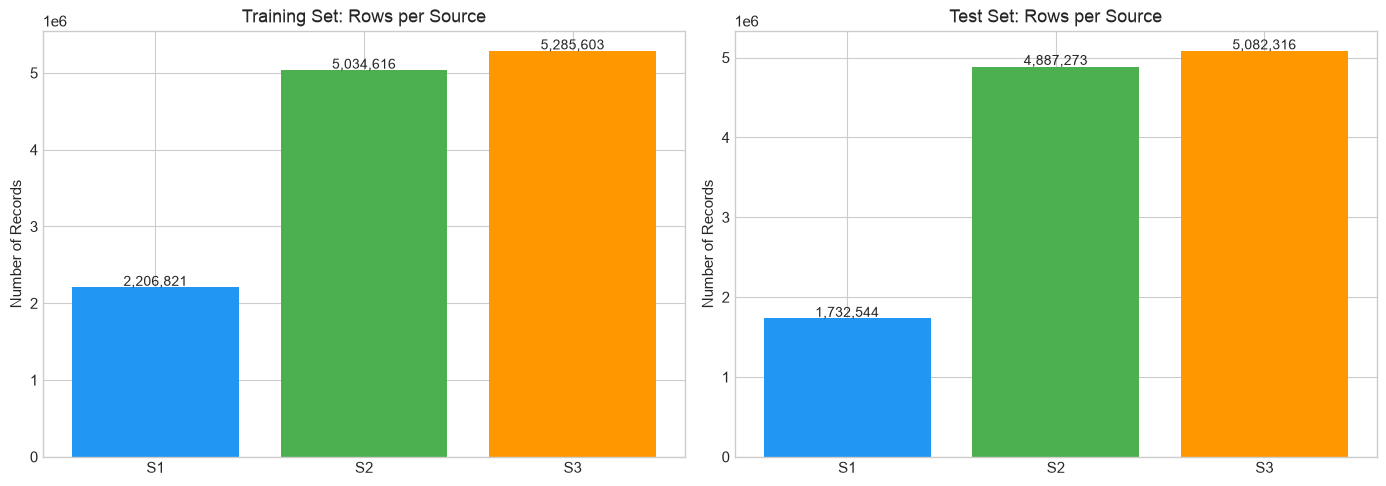

In [37]:
# Figure 1: Rows per source
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_sizes = {'S1': len(train_s1), 'S2': len(train_s2), 'S3': len(train_s3)}
test_sizes = {'S1': len(test_s1), 'S2': len(test_s2), 'S3': len(test_s3)}

axes[0].bar(train_sizes.keys(), train_sizes.values(), color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0].set_title('Training Set: Rows per Source')
axes[0].set_ylabel('Number of Records')
for i, (k, v) in enumerate(train_sizes.items()):
    axes[0].text(i, v + 20000, f'{v:,}', ha='center', fontsize=10)

axes[1].bar(test_sizes.keys(), test_sizes.values(), color=['#2196F3', '#4CAF50', '#FF9800'])
axes[1].set_title('Test Set: Rows per Source')
axes[1].set_ylabel('Number of Records')
for i, (k, v) in enumerate(test_sizes.items()):
    axes[1].text(i, v + 20000, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_rows_per_source.png', dpi=100, bbox_inches='tight')
plt.show()

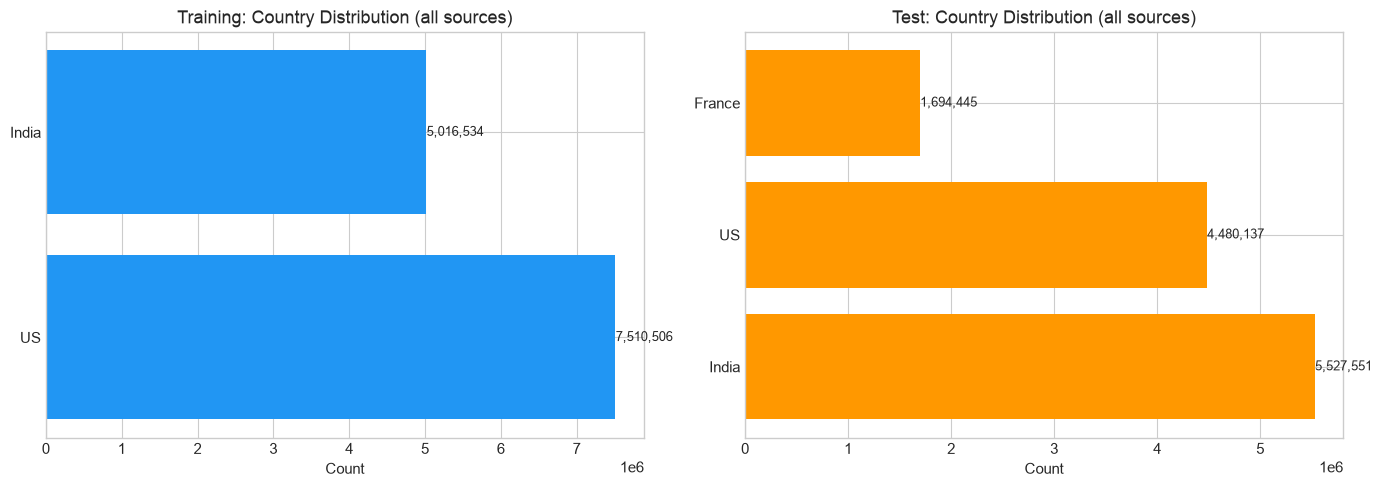

In [38]:
# Figure 2: Country distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
train_country_all = train_all['country'].value_counts(dropna=False)
axes[0].barh(train_country_all.index.astype(str), train_country_all.values, color='#2196F3')
axes[0].set_title('Training: Country Distribution (all sources)')
axes[0].set_xlabel('Count')
for i, v in enumerate(train_country_all.values):
    axes[0].text(v + 5000, i, f'{v:,}', va='center', fontsize=9)

# Test
test_country_all = test_all['country'].value_counts(dropna=False)
axes[1].barh(test_country_all.index.astype(str), test_country_all.values, color='#FF9800')
axes[1].set_title('Test: Country Distribution (all sources)')
axes[1].set_xlabel('Count')
for i, v in enumerate(test_country_all.values):
    axes[1].text(v + 5000, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_country_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

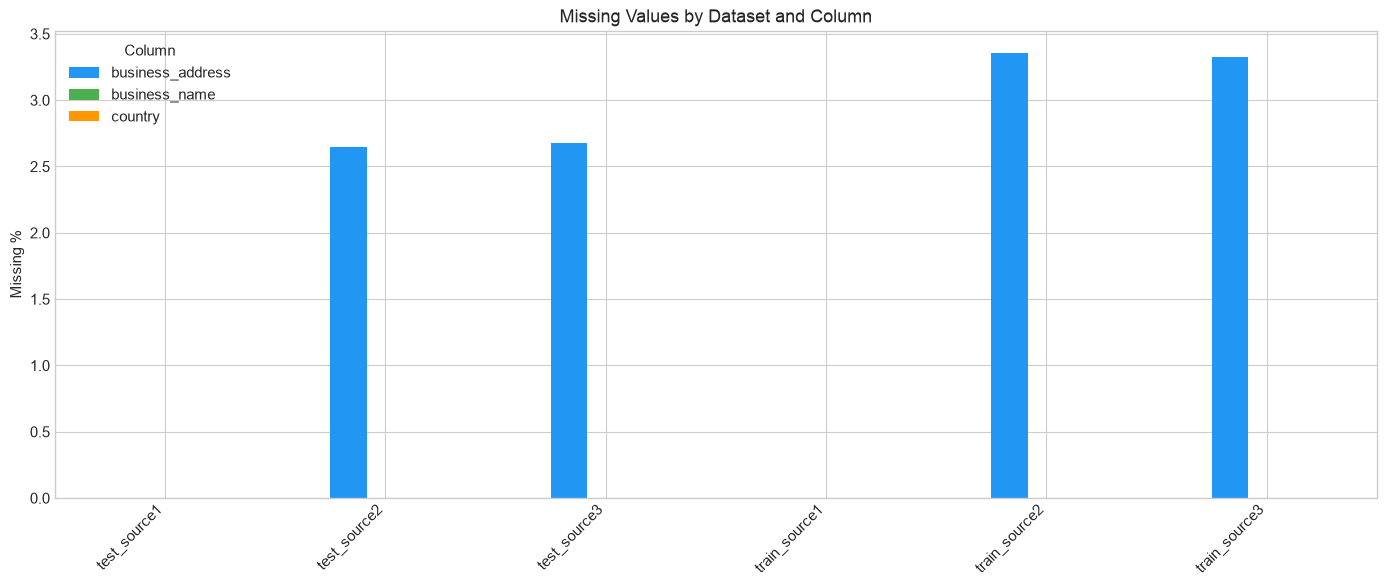

In [39]:
# Figure 3: Missing value distribution
fig, ax = plt.subplots(figsize=(14, 6))

missing_data = []
for ds_name, df in datasets.items():
    for col in ['business_name', 'business_address', 'country']:
        missing = df[col].isna() | (df[col].fillna('').str.strip() == '')
        missing_data.append({
            'Dataset': ds_name,
            'Column': col,
            'Missing %': missing.mean() * 100
        })

missing_df = pd.DataFrame(missing_data)
pivot = missing_df.pivot(index='Dataset', columns='Column', values='Missing %')
pivot.plot(kind='bar', ax=ax, color=['#2196F3', '#4CAF50', '#FF9800'])
ax.set_title('Missing Values by Dataset and Column')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
ax.legend(title='Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

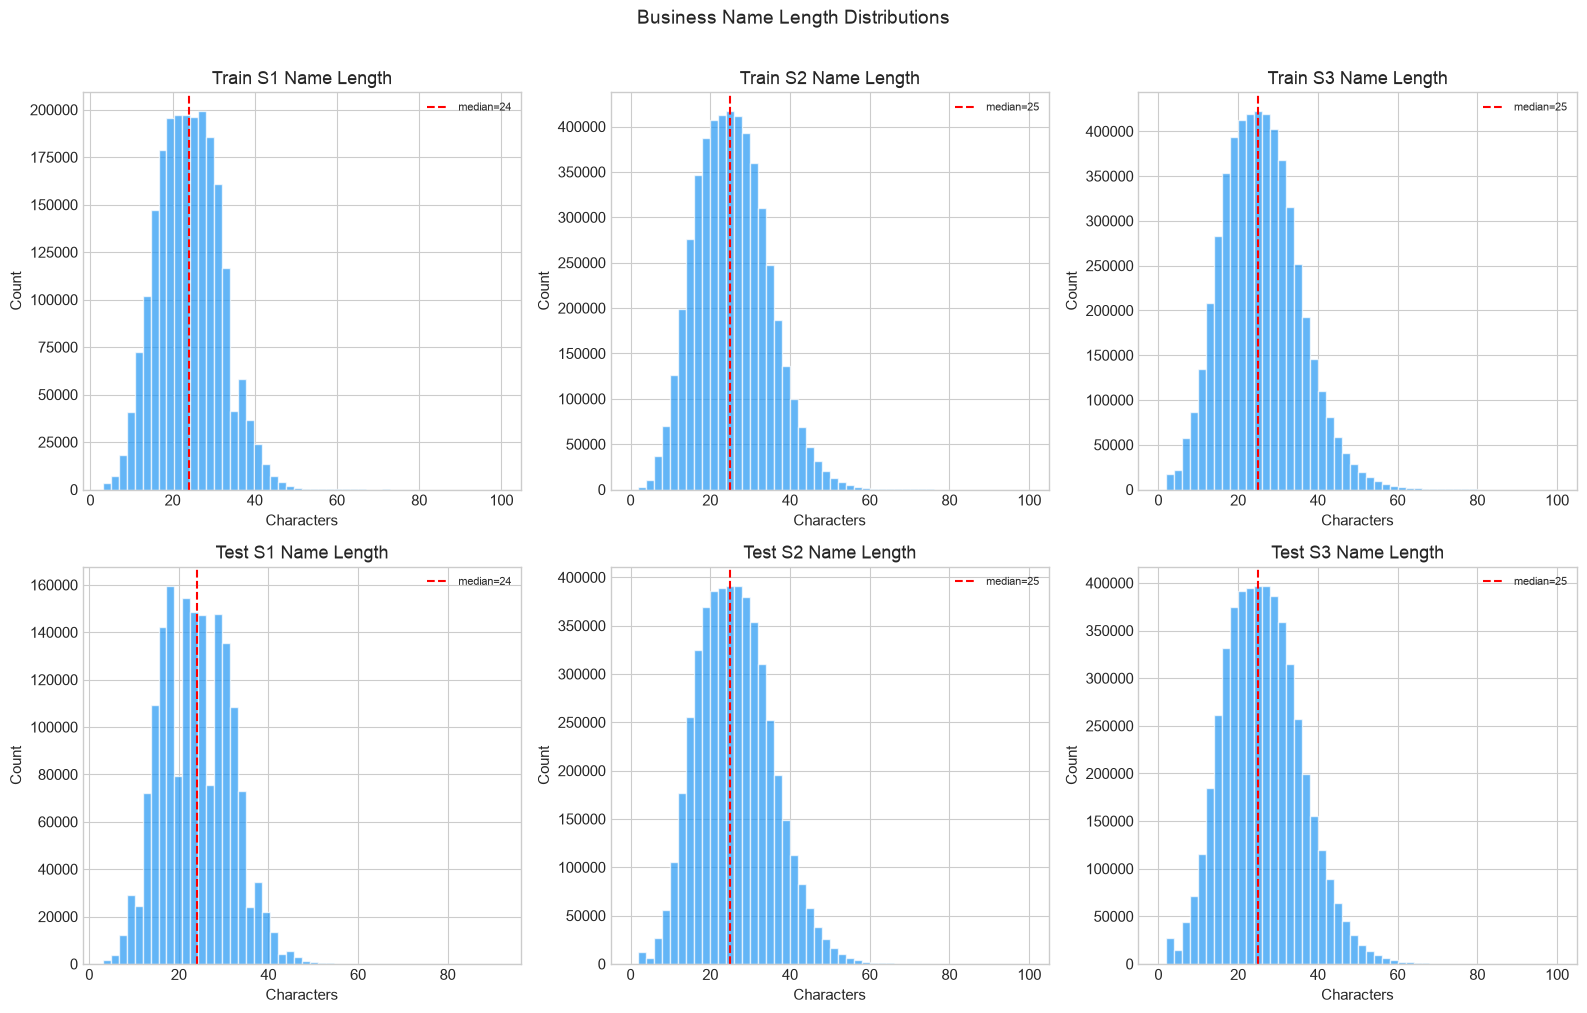

In [40]:
# Figure 4: Name length distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
all_datasets = [
    ('Train S1', train_s1), ('Train S2', train_s2), ('Train S3', train_s3),
    ('Test S1', test_s1), ('Test S2', test_s2), ('Test S3', test_s3),
]
for idx, (ds_name, df) in enumerate(all_datasets):
    ax = axes[idx // 3][idx % 3]
    name_lens = df['business_name'].fillna('').str.len()
    ax.hist(name_lens.clip(upper=100), bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
    ax.set_title(f'{ds_name} Name Length')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.axvline(name_lens.median(), color='red', linestyle='--', label=f'median={name_lens.median():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Business Name Length Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_name_length.png', dpi=100, bbox_inches='tight')
plt.show()

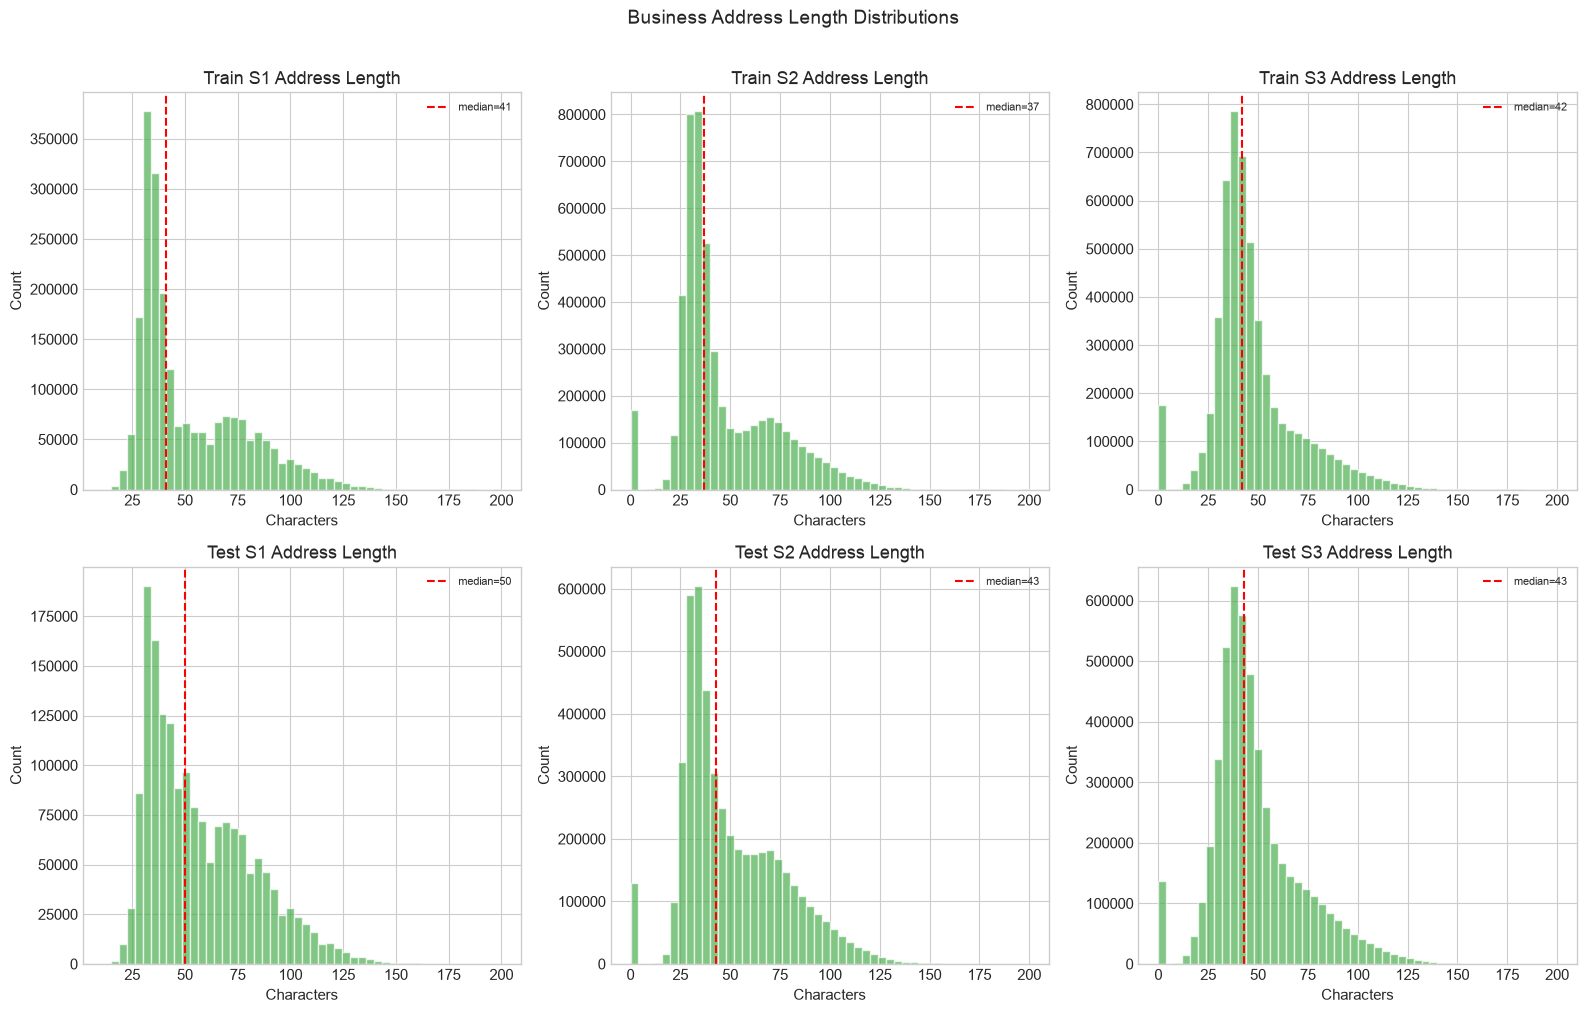

In [41]:
# Figure 5: Address length distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, (ds_name, df) in enumerate(all_datasets):
    ax = axes[idx // 3][idx % 3]
    addr_lens = df['business_address'].fillna('').str.len()
    ax.hist(addr_lens.clip(upper=200), bins=50, color='#4CAF50', alpha=0.7, edgecolor='white')
    ax.set_title(f'{ds_name} Address Length')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.axvline(addr_lens.median(), color='red', linestyle='--', label=f'median={addr_lens.median():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Business Address Length Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_address_length.png', dpi=100, bbox_inches='tight')
plt.show()

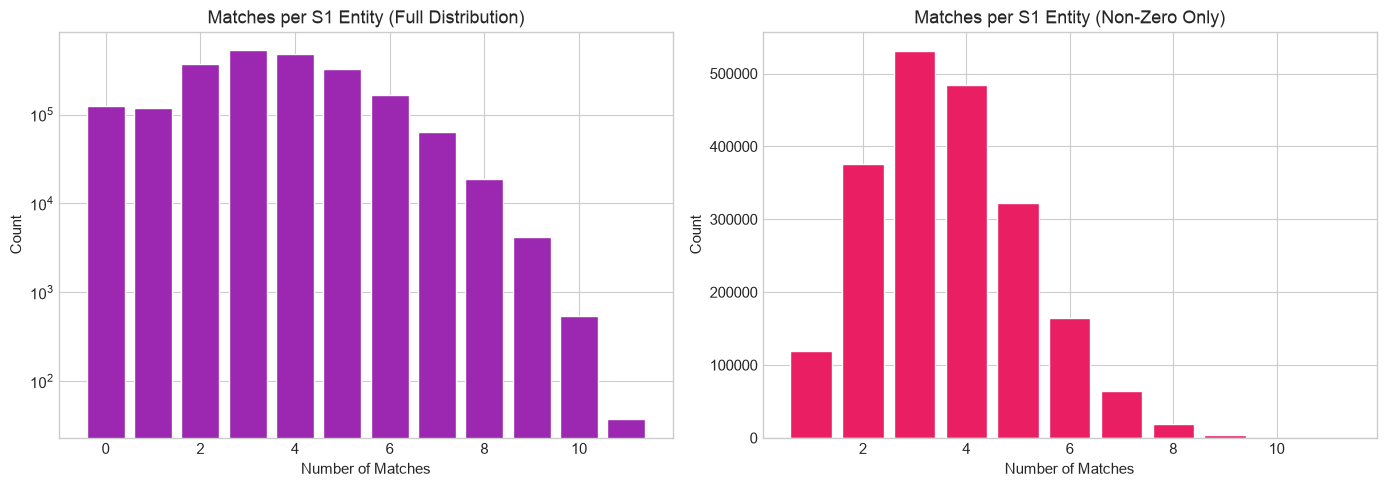

In [42]:
# Figure 6: Matches per S1 distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
match_dist_plot = gt['num_matches'].value_counts().sort_index()
axes[0].bar(match_dist_plot.index, match_dist_plot.values, color='#9C27B0', edgecolor='white')
axes[0].set_title('Matches per S1 Entity (Full Distribution)')
axes[0].set_xlabel('Number of Matches')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')

# Zoomed: non-zero only
nonzero_dist = gt[gt['num_matches'] > 0]['num_matches'].value_counts().sort_index()
axes[1].bar(nonzero_dist.index, nonzero_dist.values, color='#E91E63', edgecolor='white')
axes[1].set_title('Matches per S1 Entity (Non-Zero Only)')
axes[1].set_xlabel('Number of Matches')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_matches_per_s1.png', dpi=100, bbox_inches='tight')
plt.show()

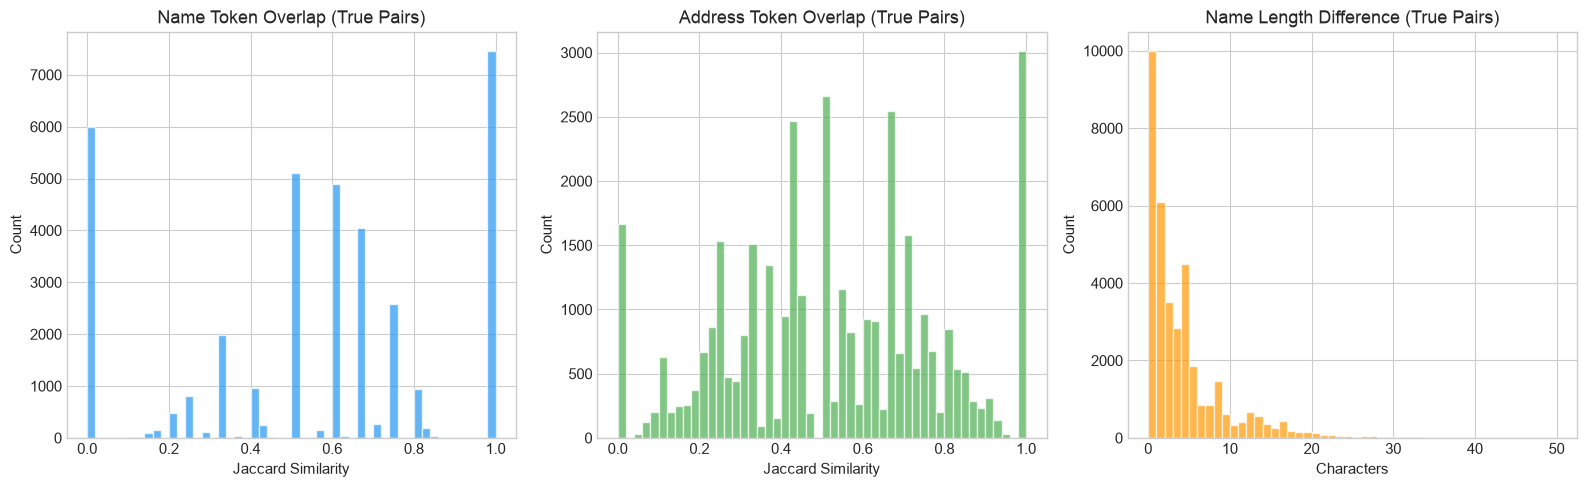

In [43]:
# Figure 7: True-match similarity distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(true_pairs['name_token_overlap'], bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0].set_title('Name Token Overlap (True Pairs)')
axes[0].set_xlabel('Jaccard Similarity')
axes[0].set_ylabel('Count')

axes[1].hist(true_pairs['addr_token_overlap'], bins=50, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1].set_title('Address Token Overlap (True Pairs)')
axes[1].set_xlabel('Jaccard Similarity')
axes[1].set_ylabel('Count')

axes[2].hist(true_pairs['name_len_diff'].clip(upper=50), bins=50, color='#FF9800', alpha=0.7, edgecolor='white')
axes[2].set_title('Name Length Difference (True Pairs)')
axes[2].set_xlabel('Characters')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_true_match_similarity.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. EDA Conclusions
### Findings that will influence Phase 2

In [44]:
print("=" * 80)
print("📋 EDA CONCLUSIONS — Findings that will influence Phase 2")
print("=" * 80)

print("\n🅰️  CONFIRMED OBSERVATIONS FROM THE DATA:")
print("-" * 50)
print(f"1. Dataset scale: ~{len(train_s1)/1e6:.1f}M S1 train, ~{len(train_s2)/1e6:.1f}M S2, ~{len(train_s3)/1e6:.1f}M S3")
print(f"2. Singleton rate: {zero_match/total_s1*100:.1f}% of S1 entities have NO matches")
print(f"3. Multi-match rate: {multi_match/total_s1*100:.1f}% of S1 have >1 match")
print(f"4. Countries in train: {sorted(train_country_set)}")
print(f"5. Unseen test countries: {sorted(unseen)}")
print(f"6. S2/S3 multi-S1 mapping: S2→{s2_multi_count}, S3→{s3_multi_count}")
print(f"7. Name exact match rate among true pairs: {true_pairs['name_exact_match'].mean()*100:.1f}%")
print(f"8. Name normalized match rate: {true_pairs['name_normalized_match'].mean()*100:.1f}%")
print(f"9. Country agreement in true pairs: {true_pairs['country_match'].mean()*100:.1f}%")
print(f"10. Source-specific formatting: S2 has ALL CAPS addresses, S3 has full state names")

devanagari_s2 = train_s2['business_name'].fillna('').str.contains(r'[\u0900-\u097F]', regex=True).sum()
devanagari_pct = devanagari_s2 / len(train_s2) * 100
print(f"11. Devanagari names in S2: {devanagari_pct:.1f}%")

missing_addr_s3 = (train_s3['business_address'].isna() | (train_s3['business_address'].str.strip() == '')).mean() * 100
print(f"12. Missing addresses in S3: {missing_addr_s3:.1f}%")

print(f"\n🅱️  HYPOTHESES TO TEST IN PHASE 2:")
print("-" * 50)
print("1. High abbreviation noise (Corp/Corporation, Ltd/Limited, Pvt/Private) → normalize legal suffixes")
print("2. Transliteration matching needed for Devanagari ↔ Latin name pairs")
print("3. Address-heavy matching may be needed when names are generic")
print("4. Source-specific address formatting (state abbrev vs full, reordering) → needs normalization")
print("5. Singleton prediction is critical for F0.5 score (large % of entities)")
print("6. Unseen country handling must be language-agnostic (no hardcoded country logic)")
print("7. '&' vs 'and', punctuation differences are systematic → rule-based normalization")
print("8. Multiple S2/S3 matches per S1 → candidate generation must not limit to top-1")

print("\n" + "=" * 80)

📋 EDA CONCLUSIONS — Findings that will influence Phase 2

🅰️  CONFIRMED OBSERVATIONS FROM THE DATA:
--------------------------------------------------
1. Dataset scale: ~2.2M S1 train, ~5.0M S2, ~5.3M S3
2. Singleton rate: 5.6% of S1 entities have NO matches
3. Multi-match rate: 89.0% of S1 have >1 match
4. Countries in train: ['India', 'US']
5. Unseen test countries: ['France']
6. S2/S3 multi-S1 mapping: S2→0, S3→0
7. Name exact match rate among true pairs: 4.6%
8. Name normalized match rate: 15.5%
9. Country agreement in true pairs: 100.0%
10. Source-specific formatting: S2 has ALL CAPS addresses, S3 has full state names


11. Devanagari names in S2: 5.4%


12. Missing addresses in S3: 3.3%

🅱️  HYPOTHESES TO TEST IN PHASE 2:
--------------------------------------------------
1. High abbreviation noise (Corp/Corporation, Ltd/Limited, Pvt/Private) → normalize legal suffixes
2. Transliteration matching needed for Devanagari ↔ Latin name pairs
3. Address-heavy matching may be needed when names are generic
4. Source-specific address formatting (state abbrev vs full, reordering) → needs normalization
5. Singleton prediction is critical for F0.5 score (large % of entities)
6. Unseen country handling must be language-agnostic (no hardcoded country logic)
7. '&' vs 'and', punctuation differences are systematic → rule-based normalization
8. Multiple S2/S3 matches per S1 → candidate generation must not limit to top-1



## 11. Generate EDA Report

In [45]:
# Collect all statistics for the report
report_lines = []
report_lines.append("# EDA Report — Business Entity Resolution Challenge")
report_lines.append("")
report_lines.append("## 1. Dataset Overview")
report_lines.append("")
report_lines.append("| Dataset | Rows | Unique IDs | Dup IDs | Fully Dup Rows |")
report_lines.append("|---------|------|-----------|---------|----------------|")
for _, row in overview_df.iterrows():
    report_lines.append(f"| {row['Dataset']} | {row['Rows']:,} | {row['Unique entity_id']:,} | "
                        f"{row['Duplicate entity_ids']:,} | {row['Fully Duplicated Rows']:,} |")

report_lines.append("")
report_lines.append("**Columns:** `entity_id`, `business_name`, `business_address`, `country`")
report_lines.append("")
report_lines.append(f"**Ground Truth:** {len(gt):,} rows, matching S1 entities to S2/S3.")

report_lines.append("")
report_lines.append("## 2. Data Quality Findings")
report_lines.append("")

# Missing values summary
report_lines.append("### Missing Values")
report_lines.append("")
report_lines.append("| Dataset | Missing Names | Missing Addresses | Missing Country |")
report_lines.append("|---------|--------------|-------------------|-----------------|")
for ds_name, df in datasets.items():
    mn = (df['business_name'].isna() | (df['business_name'].fillna('').str.strip() == '')).sum()
    ma = (df['business_address'].isna() | (df['business_address'].fillna('').str.strip() == '')).sum()
    mc = (df['country'].isna() | (df['country'].fillna('').str.strip() == '')).sum()
    report_lines.append(f"| {ds_name} | {mn:,} ({mn/len(df)*100:.2f}%) | "
                        f"{ma:,} ({ma/len(df)*100:.2f}%) | {mc:,} ({mc/len(df)*100:.2f}%) |")

report_lines.append("")
report_lines.append("### Duplicate Names")
report_lines.append("")
report_lines.append("Names appearing more than once (exact string match) exist across all sources.")
report_lines.append("This indicates generic business names that could cause false positive matches.")

report_lines.append("")
report_lines.append("### Character/Unicode Analysis")
report_lines.append("")
report_lines.append("- Devanagari script names are prevalent in Source 2 (Indian entities)")
report_lines.append("- Source 3 contains web-domain style names (e.g., `wilfordhancock.com`)")
report_lines.append("- Accented Latin characters appear in test data (French entities)")
report_lines.append("- Some names start with special characters (`<<`, `--`)")

report_lines.append("")
report_lines.append("## 3. Name Noise Findings")
report_lines.append("")
report_lines.append("Key patterns observed:")
report_lines.append("- **Legal suffix variations:** Inc/Incorporated, Corp/Corporation, Ltd/Limited, Pvt/Private, LLC, LLP")
report_lines.append("- **Punctuation:** `&` vs `and`, periods, commas, apostrophes")
report_lines.append("- **Capitalization:** Mixed case in S1, ALL CAPS common in S2")
report_lines.append("- **DBA/Trade names:** Some records contain DBA patterns")
report_lines.append("- **Web-domain names:** `.com`, `.net` suffixes in S3")
report_lines.append("- **Transliteration:** Devanagari ↔ Latin script for Indian entities")
report_lines.append("- **Special prefixes:** `<<`, `--` appear as name prefixes in some sources")

report_lines.append("")
report_lines.append("## 4. Address Noise Findings")
report_lines.append("")
report_lines.append("Key patterns observed:")
report_lines.append("- **Abbreviations:** St/Street, Rd/Road, Ave/Avenue, Blvd/Boulevard")
report_lines.append("- **State format:** S1 uses 2-letter abbreviations (TX), S3 uses full names (Texas)")
report_lines.append("- **Component reordering:** S2 sometimes puts city/state before street")
report_lines.append("- **Landmark references:** `Near`, `Opp.`, `Behind` common in Indian addresses")
report_lines.append("- **Land references:** `KH NO`, `KHASRA` in Indian source data")
report_lines.append("- **Missing addresses:** Significant portion of S3 has empty addresses")
report_lines.append("- **ALL CAPS:** S2 addresses are frequently fully capitalized")

report_lines.append("")
report_lines.append("## 5. Ground Truth Statistics")
report_lines.append("")
report_lines.append(f"- **Total S1 entities:** {total_s1:,}")
report_lines.append(f"- **Total positive links:** {total_positive_links:,}")
report_lines.append(f"- **Zero-match (singleton):** {zero_match:,} ({zero_match/total_s1*100:.2f}%)")
report_lines.append(f"- **Single-match:** {single_match:,} ({single_match/total_s1*100:.2f}%)")
report_lines.append(f"- **Multi-match (>1):** {multi_match:,} ({multi_match/total_s1*100:.2f}%)")

report_lines.append("")
report_lines.append("### Match Distribution")
report_lines.append("")
report_lines.append("| Matches | Count | Percentage |")
report_lines.append("|---------|-------|------------|")
for n_matches, count in match_dist.items():
    pct = count / total_s1 * 100
    report_lines.append(f"| {n_matches} | {count:,} | {pct:.2f}% |")

report_lines.append("")
report_lines.append("### S1→S2 / S1→S3 Breakdown")
report_lines.append("")
report_lines.append(f"- S1→S2 links: {total_s2_links:,}")
report_lines.append(f"- S1→S3 links: {total_s3_links:,}")
report_lines.append(f"- S1 with S2 match: {has_s2:,} ({has_s2/total_s1*100:.2f}%)")
report_lines.append(f"- S1 with S3 match: {has_s3:,} ({has_s3/total_s1*100:.2f}%)")
report_lines.append(f"- S1 with BOTH: {has_both:,} ({has_both/total_s1*100:.2f}%)")

report_lines.append("")
report_lines.append("## 6. Multi-Match / Uniqueness Analysis")
report_lines.append("")
report_lines.append(f"- **S2 IDs linked to multiple S1 IDs:** {s2_multi_count}")
report_lines.append(f"- **S3 IDs linked to multiple S1 IDs:** {s3_multi_count}")
if s2_multi_count == 0 and s3_multi_count == 0:
    report_lines.append("")
    report_lines.append("**No S2/S3 entity maps to multiple S1 entities.**")
    report_lines.append("This means each S2/S3 record belongs to at most one S1 entity.")
    report_lines.append("A uniqueness constraint *could* be justified but should be validated on test data.")
else:
    report_lines.append("")
    report_lines.append("**Many-to-many relationships exist.** Do NOT impose uniqueness constraints.")

report_lines.append("")
report_lines.append("## 7. Country Analysis")
report_lines.append("")
report_lines.append(f"- **Training countries:** {sorted(train_country_set)}")
report_lines.append(f"- **Test countries:** {sorted(test_country_set)}")
report_lines.append(f"- **Unseen in test:** {sorted(unseen) if unseen else 'None'}")
if unseen:
    for c in sorted(unseen):
        cnt = test_all[test_all['country'] == c].shape[0]
        report_lines.append(f"  - `{c}`: {cnt:,} test records with zero training examples")

report_lines.append("")
report_lines.append("### Match Rate by Country (Training)")
report_lines.append("")
report_lines.append(country_match_stats.to_markdown(index=False))

report_lines.append("")
report_lines.append("## 8. True-Match Characteristics")
report_lines.append("")
report_lines.append(f"Based on {len(true_pairs):,} sampled true-match pairs:")
report_lines.append("")
report_lines.append(f"- Name exact match: {true_pairs['name_exact_match'].mean()*100:.2f}%")
report_lines.append(f"- Name normalized match: {true_pairs['name_normalized_match'].mean()*100:.2f}%")
report_lines.append(f"- Country agreement: {true_pairs['country_match'].mean()*100:.2f}%")
report_lines.append(f"- Mean name token overlap: {true_pairs['name_token_overlap'].mean():.3f}")
report_lines.append(f"- Mean address token overlap: {true_pairs['addr_token_overlap'].mean():.3f}")
report_lines.append(f"- Mean name length difference: {true_pairs['name_len_diff'].mean():.1f} chars")
report_lines.append(f"- Mean address length difference: {true_pairs['addr_len_diff'].mean():.1f} chars")

report_lines.append("")
report_lines.append("### Difficulty Breakdown (True Pairs)")
report_lines.append("")
easy_pct = (true_pairs['name_token_overlap'] > 0.8).mean() * 100
medium_pct = ((true_pairs['name_token_overlap'] >= 0.3) & (true_pairs['name_token_overlap'] <= 0.8)).mean() * 100
hard_pct = (true_pairs['name_token_overlap'] < 0.3).mean() * 100
report_lines.append(f"- Easy (name overlap > 0.8): {easy_pct:.1f}%")
report_lines.append(f"- Medium (0.3–0.8): {medium_pct:.1f}%")
report_lines.append(f"- Hard (< 0.3): {hard_pct:.1f}%")

report_lines.append("")
report_lines.append("## 9. Key Risks for Phase 2")
report_lines.append("")
report_lines.append("1. **High singleton rate** — large % of S1 entities have no matches; correctly identifying these is crucial for F0.5")
report_lines.append("2. **Transliteration challenge** — Devanagari ↔ Latin name matching for Indian entities")
report_lines.append("3. **Unseen country** — France appears only in test; pipeline must be language-agnostic")
report_lines.append("4. **Generic names** — common business names appear frequently, requiring address-based disambiguation")
report_lines.append("5. **Missing addresses** — significant portion of records lack addresses, limiting matching signals")
report_lines.append("6. **Source-specific formatting** — each source has distinct normalization patterns")
report_lines.append("7. **Scale** — millions of records require efficient blocking/candidate generation")
report_lines.append("8. **Multi-match complexity** — many S1 entities match multiple S2/S3 records")

report_lines.append("")
report_lines.append("## 10. Phase 2 Implications")
report_lines.append("")
report_lines.append("- Normalization pipeline must handle: legal suffixes, &/and, punctuation, case, Devanagari, French accents")
report_lines.append("- Blocking strategy must balance recall (many potential pairs) with efficiency (millions of records)")
report_lines.append("- Feature engineering should include: name similarity, address similarity, country match, length features")
report_lines.append("- Model must handle unseen country (France) gracefully — no country-specific hardcoding")
report_lines.append("- Singleton detection should be a dedicated component to maximize F0.5")
report_lines.append("- Address normalization must handle US state abbrevs, Indian landmarks, French addresses")

report_content = '\n'.join(report_lines)

with open(DOCS_DIR / 'eda_report.md', 'w') as f:
    f.write(report_content)

print(f"✅ EDA report written to {DOCS_DIR / 'eda_report.md'}")

✅ EDA report written to /Users/akashmacbook/Desktop/business-entity-resolution/docs/eda_report.md


In [46]:
# Final verification
print("\n" + "=" * 80)
print("📋 FINAL VERIFICATION")
print("=" * 80)
assert (DOCS_DIR / 'eda_report.md').exists(), "EDA report not found!"
print("✅ docs/eda_report.md exists")

# Verify dataset files were not modified (check row counts)
verify_s1 = pd.read_csv(TRAIN_DIR / 'train_source1.tsv', sep='\t', nrows=5)
assert list(verify_s1.columns) == ['entity_id', 'business_name', 'business_address', 'country']
print("✅ Dataset files not modified (spot check passed)")
print("✅ Phase 1 EDA Complete!")


📋 FINAL VERIFICATION
✅ docs/eda_report.md exists
✅ Dataset files not modified (spot check passed)
✅ Phase 1 EDA Complete!
